# Cardiovascular Disease Prediction Using Machine Learning

## Project Objective

Cardiovascular disease is one of the major causes of death worldwide. Early identification of cardiovascular disease risk can support timely medical intervention and treatment.

The objective of this project is to analyse cardiovascular health data, perform data preprocessing and exploratory data analysis, study the correlation between different health features, and develop a machine learning model for cardiovascular disease detection.

Five machine learning algorithms are evaluated in this project:

- Logistic Regression
- K-Nearest Neighbour (KNN)
- Support Vector Machine (SVM)
- Decision Tree
- Random Forest

The performance of these models is compared based on their accuracy, and the best-performing model is selected to build the final cardiovascular disease detection system.

## 1. Importing Required Libraries

The required Python libraries are imported for data processing, numerical operations, data visualisation, machine learning model development, and model evaluation.

In [4]:
# Core data workspace
import pandas as pd
import numpy as np

# Visual exploration
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset preparation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Required cardiovascular prediction models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Performance assessment
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")


# ---------------------------------------------------------
# PROJECT CONFIGURATION
# ---------------------------------------------------------

PROJECT_SEED = 42
TARGET_FEATURE = "cardio"

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:.3f}")

sns.set_theme(
    context="notebook",
    style="whitegrid"
)

print("CardioML workspace initialized.")
print(f"Reproducibility seed : {PROJECT_SEED}")
print(f"Prediction target    : {TARGET_FEATURE}")

CardioML workspace initialized.
Reproducibility seed : 42
Prediction target    : cardio


## 2. Dataset Ingestion and Source Preservation

The cardiovascular dataset is loaded from the source CSV file for analysis. Since the source file contains semicolon-separated values, the appropriate delimiter is specified during ingestion.

Two dataset objects are maintained. The original dataset is preserved without modification, while a separate working copy is created for preprocessing, exploration, and model development. This makes the cleaning process traceable and allows the processed dataset to be compared with its original state.

In [5]:
# ---------------------------------------------------------
# DATASET INGESTION
# ---------------------------------------------------------

DATASET_PATH = "cardio_train.csv"

cardio_raw = pd.read_csv(
    DATASET_PATH,
    sep=";"
)

# Preserve the source data and create an independent workspace
cardio_data = cardio_raw.copy(deep=True)

record_count, feature_count = cardio_data.shape

print("CARDIOVASCULAR DATASET SNAPSHOT")
print("-" * 46)
print(f"Source file          : {DATASET_PATH}")
print(f"Patient records      : {record_count:,}")
print(f"Recorded columns     : {feature_count}")
print(f"Prediction target    : {TARGET_FEATURE}")
print(f"Working copy created : {cardio_data is not cardio_raw}")
print("-" * 46)

cardio_data.head()

CARDIOVASCULAR DATASET SNAPSHOT
----------------------------------------------
Source file          : cardio_train.csv
Patient records      : 70,000
Recorded columns     : 13
Prediction target    : cardio
Working copy created : True
----------------------------------------------


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.000,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.000,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.000,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.000,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.000,100,60,1,1,0,0,0,0


## 3. Structural Dataset Profiling

Before performing preprocessing, the raw cardiovascular dataset is examined to understand its structure and data quality. The profiling stage evaluates column definitions, data types, missing observations, duplicate patient records, feature cardinality, and the distribution of the prediction target.

This initial assessment is used to identify the preprocessing operations required by the dataset rather than applying arbitrary cleaning steps.

In [6]:
# ---------------------------------------------------------
# STRUCTURAL DATASET AUDIT
# ---------------------------------------------------------

schema_audit = pd.DataFrame({
    "Feature": cardio_data.columns,
    "Data Type": cardio_data.dtypes.astype(str).values,
    "Missing": cardio_data.isna().sum().values,
    "Missing (%)": (
        cardio_data.isna().mean().values * 100
    ),
    "Unique Values": cardio_data.nunique().values
})

schema_audit["Missing (%)"] = schema_audit["Missing (%)"].round(2)

print("CARDIOML STRUCTURAL AUDIT")
print("-" * 72)

display(schema_audit)

print("-" * 72)
print(f"Dataset dimensions : {cardio_data.shape[0]:,} rows × {cardio_data.shape[1]} columns")
print(f"Total missing cells: {cardio_data.isna().sum().sum():,}")

CARDIOML STRUCTURAL AUDIT
------------------------------------------------------------------------


,Feature,Data Type,Missing,Missing (%),Unique Values
0,id,int64,0,0.000,70000
1,age,int64,0,0.000,8076
2,gender,int64,0,0.000,2
3,height,int64,0,0.000,109
4,weight,float64,0,0.000,287
5,ap_hi,int64,0,0.000,153
6,ap_lo,int64,0,0.000,157
7,cholesterol,int64,0,0.000,3
8,gluc,int64,0,0.000,3
9,smoke,int64,0,0.000,2


------------------------------------------------------------------------
Dataset dimensions : 70,000 rows × 13 columns
Total missing cells: 0


In [7]:
# ---------------------------------------------------------
# DATA QUALITY LEDGER
# ---------------------------------------------------------

duplicate_count = cardio_data.duplicated().sum()
missing_count = cardio_data.isna().sum().sum()

identifier_unique = cardio_data["id"].nunique()
target_classes = sorted(cardio_data[TARGET_FEATURE].unique().tolist())

quality_ledger = {
    "Patient records inspected": len(cardio_data),
    "Completely duplicated rows": duplicate_count,
    "Missing data cells": missing_count,
    "Unique patient identifiers": identifier_unique,
    "Target classes discovered": target_classes
}

print("DATA QUALITY LEDGER")
print("-" * 52)

for checkpoint, result in quality_ledger.items():
    if isinstance(result, int):
        result = f"{result:,}"

    print(f"{checkpoint:<32} : {result}")

print("-" * 52)

DATA QUALITY LEDGER
----------------------------------------------------
Patient records inspected        : 70,000
Completely duplicated rows       : 0
Missing data cells               : 0
Unique patient identifiers       : 70,000
Target classes discovered        : [0, 1]
----------------------------------------------------


In [8]:
# ---------------------------------------------------------
# CLINICAL RECORD DUPLICATE INVESTIGATION
# ---------------------------------------------------------

clinical_columns = [
    column
    for column in cardio_data.columns
    if column != "id"
]

clinical_duplicate_mask = cardio_data.duplicated(
    subset=clinical_columns,
    keep=False
)

clinical_duplicate_rows = clinical_duplicate_mask.sum()

repeated_clinical_records = cardio_data.duplicated(
    subset=clinical_columns,
    keep="first"
).sum()

print("CLINICAL DUPLICATE INVESTIGATION")
print("-" * 56)
print(f"Complete row duplicates           : {duplicate_count:,}")
print(f"Rows involved in repeated profiles: {clinical_duplicate_rows:,}")
print(f"Repeated clinical records         : {repeated_clinical_records:,}")
print("-" * 56)

if repeated_clinical_records == 0:
    print("Finding: No repeated clinical records were detected.")
else:
    print(
        "Finding: Repeated clinical profiles exist when the "
        "patient identifier is excluded."
    )

CLINICAL DUPLICATE INVESTIGATION
--------------------------------------------------------
Complete row duplicates           : 0
Rows involved in repeated profiles: 48
Repeated clinical records         : 24
--------------------------------------------------------
Finding: Repeated clinical profiles exist when the patient identifier is excluded.


In [9]:
# ---------------------------------------------------------
# TARGET BALANCE PROFILE
# ---------------------------------------------------------

target_profile = (
    cardio_data[TARGET_FEATURE]
    .value_counts()
    .sort_index()
    .rename_axis("Cardio Class")
    .reset_index(name="Patients")
)

target_profile["Class Meaning"] = target_profile["Cardio Class"].map({
    0: "No Cardiovascular Disease",
    1: "Cardiovascular Disease"
})

target_profile["Dataset Share (%)"] = (
    target_profile["Patients"] / len(cardio_data) * 100
).round(2)

target_profile = target_profile[
    [
        "Cardio Class",
        "Class Meaning",
        "Patients",
        "Dataset Share (%)"
    ]
]

print("CARDIOVASCULAR TARGET BALANCE")
print("-" * 72)

display(target_profile)

class_gap = abs(
    target_profile.loc[0, "Dataset Share (%)"]
    - target_profile.loc[1, "Dataset Share (%)"]
)

print(f"Absolute class distribution gap: {class_gap:.2f} percentage points")

if class_gap <= 10:
    print(
        "Assessment: The prediction target is reasonably balanced. "
        "No immediate class-resampling operation is required."
    )
else:
    print(
        "Assessment: A notable target imbalance is present and "
        "should be considered during model preparation."
    )

CARDIOVASCULAR TARGET BALANCE
------------------------------------------------------------------------


,Cardio Class,Class Meaning,Patients,Dataset Share (%)
0,0,No Cardiovascular Disease,35021,50.030
1,1,Cardiovascular Disease,34979,49.970


Absolute class distribution gap: 0.06 percentage points
Assessment: The prediction target is reasonably balanced. No immediate class-resampling operation is required.


In [10]:
# ---------------------------------------------------------
# NUMERICAL BOUNDARY SCAN
# ---------------------------------------------------------

boundary_features = [
    "age",
    "height",
    "weight",
    "ap_hi",
    "ap_lo"
]

boundary_scan = cardio_data[boundary_features].agg([
    "min",
    "median",
    "mean",
    "max"
]).T

boundary_scan.columns = [
    "Minimum",
    "Median",
    "Mean",
    "Maximum"
]

boundary_scan["Range Span"] = (
    boundary_scan["Maximum"] - boundary_scan["Minimum"]
)

print("RAW PHYSIOLOGICAL BOUNDARY SCAN")
print("-" * 72)

display(boundary_scan.round(2))

RAW PHYSIOLOGICAL BOUNDARY SCAN
------------------------------------------------------------------------


,Minimum,Median,Mean,Maximum,Range Span
age,10798.000,19703.000,19468.870,23713.000,12915.000
height,55.000,165.000,164.360,250.000,195.000
weight,10.000,72.000,74.210,200.000,190.000
ap_hi,-150.000,120.000,128.820,16020.000,16170.000
ap_lo,-70.000,80.000,96.630,11000.000,11070.000


## 4. Data Preprocessing and Quality Control

The initial dataset profile revealed no missing values and no complete duplicate rows. A small number of identical clinical profiles were observed after excluding the patient identifier; however, these records are retained because each observation has a unique patient ID and may represent a distinct individual with the same recorded characteristics.

The preprocessing stage therefore focuses on removing the non-predictive patient identifier, transforming age into years, and screening clearly implausible physiological measurements. Rather than applying blanket statistical outlier removal, validity rules are applied to height, weight, and blood pressure so that uncommon but potentially meaningful cardiovascular cases are not automatically discarded.

Each screening operation is recorded in a preprocessing audit trail to measure its effect on the dataset.

In [11]:
# ---------------------------------------------------------
# PREPROCESSING AUDIT ENGINE
# ---------------------------------------------------------

preprocessing_audit = []
initial_record_count = len(cardio_data)


def apply_quality_gate(data, rule, stage):
    """
    Apply a boolean validity rule and record its impact on
    the cardiovascular dataset.
    """

    records_before = len(data)

    screened_data = data.loc[rule].copy()

    records_after = len(screened_data)
    records_removed = records_before - records_after

    preprocessing_audit.append({
        "Cleaning Stage": stage,
        "Records Before": records_before,
        "Records Removed": records_removed,
        "Records Remaining": records_after,
        "Stage Retention (%)": round(
            (records_after / records_before) * 100,
            2
        )
    })

    return screened_data


print("Preprocessing audit engine initialized.")
print(f"Baseline patient records: {initial_record_count:,}")

Preprocessing audit engine initialized.
Baseline patient records: 70,000


In [12]:
# ---------------------------------------------------------
# FEATURE REFINEMENT
# ---------------------------------------------------------

# Patient ID is preserved in cardio_raw but excluded from
# the analytical and predictive workspace.
cardio_data.drop(columns="id", inplace=True)

# Convert age from recorded days into continuous years.
cardio_data["age"] = cardio_data["age"] / 365.25

print("FEATURE REFINEMENT SUMMARY")
print("-" * 54)
print("Removed feature : id")
print("Reason          : Unique identifier with no predictive role")
print("Age unit        : days -> years")
print(
    f"Age range       : "
    f"{cardio_data['age'].min():.2f} to "
    f"{cardio_data['age'].max():.2f} years"
)
print("-" * 54)

FEATURE REFINEMENT SUMMARY
------------------------------------------------------
Removed feature : id
Reason          : Unique identifier with no predictive role
Age unit        : days -> years
Age range       : 29.56 to 64.92 years
------------------------------------------------------


In [13]:
# ---------------------------------------------------------
# PHYSIOLOGICAL QUALITY GATES
# ---------------------------------------------------------

quality_gates = [
    {
        "stage": "Height plausibility screening",
        "rule": lambda data: data["height"].between(120, 220)
    },
    {
        "stage": "Weight plausibility screening",
        "rule": lambda data: data["weight"].between(30, 250)
    },
    {
        "stage": "Systolic BP plausibility screening",
        "rule": lambda data: data["ap_hi"].between(70, 250)
    },
    {
        "stage": "Diastolic BP plausibility screening",
        "rule": lambda data: data["ap_lo"].between(40, 150)
    },
    {
        "stage": "Blood pressure relationship validation",
        "rule": lambda data: data["ap_hi"] > data["ap_lo"]
    }
]


for gate in quality_gates:
    validity_rule = gate["rule"](cardio_data)

    cardio_data = apply_quality_gate(
        data=cardio_data,
        rule=validity_rule,
        stage=gate["stage"]
    )


print("Physiological quality screening completed.")
print(f"Records entering screening : {initial_record_count:,}")
print(f"Records after screening    : {len(cardio_data):,}")
print(
    f"Total records excluded     : "
    f"{initial_record_count - len(cardio_data):,}"
)

Physiological quality screening completed.
Records entering screening : 70,000
Records after screening    : 68,610
Total records excluded     : 1,390


In [14]:
# ---------------------------------------------------------
# PREPROCESSING AUDIT TRAIL
# ---------------------------------------------------------

audit_table = pd.DataFrame(preprocessing_audit)

overall_retention = (
    len(cardio_data) / initial_record_count
) * 100

overall_exclusion = 100 - overall_retention

print("CARDIOML PREPROCESSING AUDIT TRAIL")
print("-" * 82)

display(audit_table)

print("-" * 82)
print(f"Original patient records : {initial_record_count:,}")
print(f"Processed patient records: {len(cardio_data):,}")
print(
    f"Total records excluded   : "
    f"{initial_record_count - len(cardio_data):,}"
)
print(f"Overall retention rate   : {overall_retention:.2f}%")
print(f"Overall exclusion rate   : {overall_exclusion:.2f}%")

CARDIOML PREPROCESSING AUDIT TRAIL
----------------------------------------------------------------------------------


,Cleaning Stage,Records Before,Records Removed,Records Remaining,Stage Retention (%)
0,Height plausibility screening,70000,53,69947,99.920
1,Weight plausibility screening,69947,7,69940,99.990
2,Systolic BP plausibility screening,69940,227,69713,99.680
3,Diastolic BP plausibility screening,69713,1015,68698,98.540
4,Blood pressure relationship validation,68698,88,68610,99.870


----------------------------------------------------------------------------------
Original patient records : 70,000
Processed patient records: 68,610
Total records excluded   : 1,390
Overall retention rate   : 98.01%
Overall exclusion rate   : 1.99%


In [15]:
# ---------------------------------------------------------
# CARDIOVASCULAR FEATURE ENGINEERING
# ---------------------------------------------------------

height_in_metres = cardio_data["height"] / 100

cardio_data["bmi"] = (
    cardio_data["weight"] / height_in_metres.pow(2)
)

print("ENGINEERED FEATURE PROFILE")
print("-" * 54)
print("Feature created : bmi")
print("Source features : height, weight")
print(
    f"BMI range       : "
    f"{cardio_data['bmi'].min():.2f} to "
    f"{cardio_data['bmi'].max():.2f}"
)
print(
    f"Median BMI      : "
    f"{cardio_data['bmi'].median():.2f}"
)
print("-" * 54)

cardio_data[["height", "weight", "bmi"]].head()

ENGINEERED FEATURE PROFILE
------------------------------------------------------
Feature created : bmi
Source features : height, weight
BMI range       : 10.73 to 108.17
Median BMI      : 26.35
------------------------------------------------------


,height,weight,bmi
0,168,62.000,21.967
1,156,85.000,34.928
2,165,64.000,23.508
3,169,82.000,28.710
4,156,56.000,23.011


In [16]:
# ---------------------------------------------------------
# POST-PREPROCESSING INTEGRITY CHECK
# ---------------------------------------------------------

integrity_checks = {
    "No missing values":
        cardio_data.isna().sum().sum() == 0,

    "Identifier removed":
        "id" not in cardio_data.columns,

    "Age represented in years":
        cardio_data["age"].between(20, 100).all(),

    "Height values within quality gate":
        cardio_data["height"].between(120, 220).all(),

    "Weight values within quality gate":
        cardio_data["weight"].between(30, 250).all(),

    "Systolic BP within quality gate":
        cardio_data["ap_hi"].between(70, 250).all(),

    "Diastolic BP within quality gate":
        cardio_data["ap_lo"].between(40, 150).all(),

    "Systolic BP exceeds diastolic BP":
        (cardio_data["ap_hi"] > cardio_data["ap_lo"]).all(),

    "BMI values successfully generated":
        cardio_data["bmi"].notna().all()
}


integrity_table = pd.DataFrame(
    integrity_checks.items(),
    columns=["Integrity Check", "Passed"]
)

integrity_table["Status"] = integrity_table["Passed"].map({
    True: "PASS",
    False: "REVIEW"
})

print("POST-PREPROCESSING INTEGRITY REPORT")
print("-" * 72)

display(
    integrity_table[
        ["Integrity Check", "Status"]
    ]
)

passed_checks = integrity_table["Passed"].sum()
total_checks = len(integrity_table)

print(
    f"Integrity checks passed: "
    f"{passed_checks}/{total_checks}"
)

if passed_checks == total_checks:
    print(
        "Assessment: The processed dataset is ready "
        "for exploratory analysis."
    )
else:
    print(
        "Assessment: One or more preprocessing conditions "
        "require review."
    )

POST-PREPROCESSING INTEGRITY REPORT
------------------------------------------------------------------------


,Integrity Check,Status
0,No missing values,PASS
1,Identifier removed,PASS
2,Age represented in years,PASS
3,Height values within quality gate,PASS
4,Weight values within quality gate,PASS
5,Systolic BP within quality gate,PASS
6,Diastolic BP within quality gate,PASS
7,Systolic BP exceeds diastolic BP,PASS
8,BMI values successfully generated,PASS


Integrity checks passed: 9/9
Assessment: The processed dataset is ready for exploratory analysis.


### Preprocessing Findings

The preprocessing audit retained **68,610 of the original 70,000 patient records**, corresponding to an overall retention rate of **98.01%**. Only **1.99% of observations** were excluded through physiological quality screening.

Blood pressure measurements were the dominant source of data-quality anomalies. Systolic pressure screening, diastolic pressure screening, and blood-pressure relationship validation collectively accounted for **1,330 of the 1,390 excluded records**, representing approximately **95.7% of all preprocessing exclusions**. Diastolic blood pressure alone accounted for more than 70% of the removed observations.

The age feature was transformed from days to continuous years, preserving the original age resolution, while the non-predictive patient identifier was removed. BMI was additionally derived from height and weight as a cardiovascular risk-related feature.

Following preprocessing and feature engineering, all nine dataset integrity checks were successfully passed. The processed dataset is therefore considered suitable for exploratory analysis and machine learning model development.

## 5. Exploratory Data Analysis and Visualisation

Exploratory data analysis is performed on the processed cardiovascular dataset to identify patterns associated with cardiovascular disease. Rather than examining features independently through raw frequency plots, the analysis focuses on disease prevalence within patient groups.

The visual investigation is organised around demographic characteristics, body composition, blood pressure, metabolic indicators, and lifestyle factors. For each risk dimension, the proportion of cardiovascular disease cases is examined to identify groups with elevated disease prevalence.

In [17]:
# ---------------------------------------------------------
# CARDIOVASCULAR PREVALENCE ANALYSIS ENGINE
# ---------------------------------------------------------

def build_prevalence_profile(data, group_feature, label_map=None):
    """
    Summarise cardiovascular disease prevalence for each
    category of a selected patient feature.
    """

    profile = (
        data.groupby(group_feature, observed=True)[TARGET_FEATURE]
        .agg(
            Patients="size",
            CVD_Cases="sum",
            CVD_Rate="mean"
        )
        .reset_index()
    )

    profile["CVD_Rate"] = profile["CVD_Rate"] * 100

    if label_map is not None:
        profile["Patient Group"] = (
            profile[group_feature]
            .map(label_map)
            .fillna(profile[group_feature].astype(str))
        )
    else:
        profile["Patient Group"] = profile[group_feature].astype(str)

    return profile


print("Cardiovascular prevalence analysis engine initialized.")

Cardiovascular prevalence analysis engine initialized.


In [18]:
# ---------------------------------------------------------
# PROCESSED PATIENT POPULATION OVERVIEW
# ---------------------------------------------------------

population_overview = pd.DataFrame({
    "Metric": [
        "Processed Patients",
        "Mean Age",
        "Median Age",
        "Mean BMI",
        "Median BMI",
        "Mean Systolic BP",
        "Mean Diastolic BP",
        "Cardiovascular Disease Prevalence"
    ],
    "Observed Value": [
        f"{len(cardio_data):,}",
        f"{cardio_data['age'].mean():.2f} years",
        f"{cardio_data['age'].median():.2f} years",
        f"{cardio_data['bmi'].mean():.2f}",
        f"{cardio_data['bmi'].median():.2f}",
        f"{cardio_data['ap_hi'].mean():.2f} mmHg",
        f"{cardio_data['ap_lo'].mean():.2f} mmHg",
        f"{cardio_data[TARGET_FEATURE].mean() * 100:.2f}%"
    ]
})

print("PROCESSED CARDIOVASCULAR POPULATION PROFILE")
print("-" * 68)

display(population_overview)

PROCESSED CARDIOVASCULAR POPULATION PROFILE
--------------------------------------------------------------------


,Metric,Observed Value
0,Processed Patients,"68,610"
1,Mean Age,53.29 years
2,Median Age,53.94 years
3,Mean BMI,27.46
4,Median BMI,26.35
5,Mean Systolic BP,126.67 mmHg
6,Mean Diastolic BP,81.30 mmHg
7,Cardiovascular Disease Prevalence,49.47%


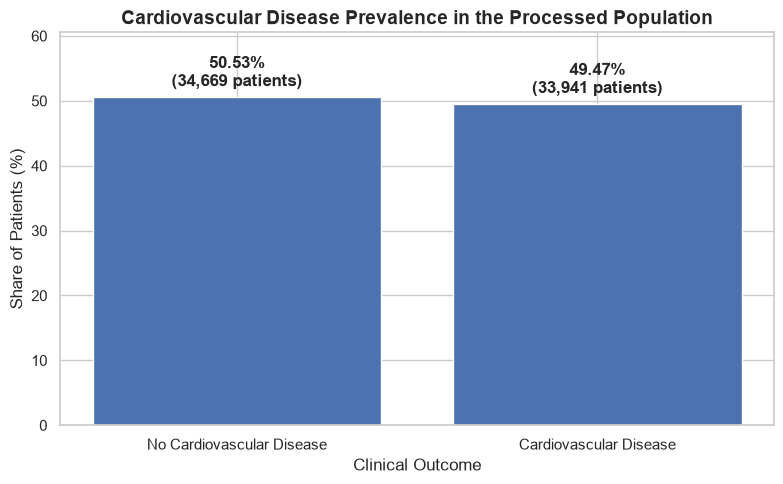

Observed CVD prevalence: 49.47%


In [19]:
# ---------------------------------------------------------
# CARDIOVASCULAR DISEASE PREVALENCE
# ---------------------------------------------------------

disease_distribution = (
    cardio_data[TARGET_FEATURE]
    .value_counts()
    .sort_index()
)

disease_labels = [
    "No Cardiovascular Disease",
    "Cardiovascular Disease"
]

disease_percentages = (
    disease_distribution / disease_distribution.sum() * 100
)

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    disease_labels,
    disease_percentages.values
)

ax.set_title(
    "Cardiovascular Disease Prevalence in the Processed Population",
    fontsize=14,
    fontweight="bold"
)

ax.set_ylabel("Share of Patients (%)")
ax.set_xlabel("Clinical Outcome")

ax.set_ylim(
    0,
    disease_percentages.max() + 10
)

for bar, percentage, patients in zip(
    bars,
    disease_percentages.values,
    disease_distribution.values
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{percentage:.2f}%\n({patients:,} patients)",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

print(
    f"Observed CVD prevalence: "
    f"{cardio_data[TARGET_FEATURE].mean() * 100:.2f}%"
)

AGE-BASED CARDIOVASCULAR RISK PROFILE
------------------------------------------------------------------------


,Patient Group,Patients,CVD_Cases,CVD_Rate
0,30-34,4,0,0.000
1,35-39,1855,438,23.610
2,40-44,8232,2516,30.560
3,45-49,11187,4768,42.620
4,50-54,16747,7711,46.040
5,55-59,18085,10168,56.220
6,60-64,12500,8340,66.720


Visual trajectory excludes 1 age group(s) with fewer than 100 patients.


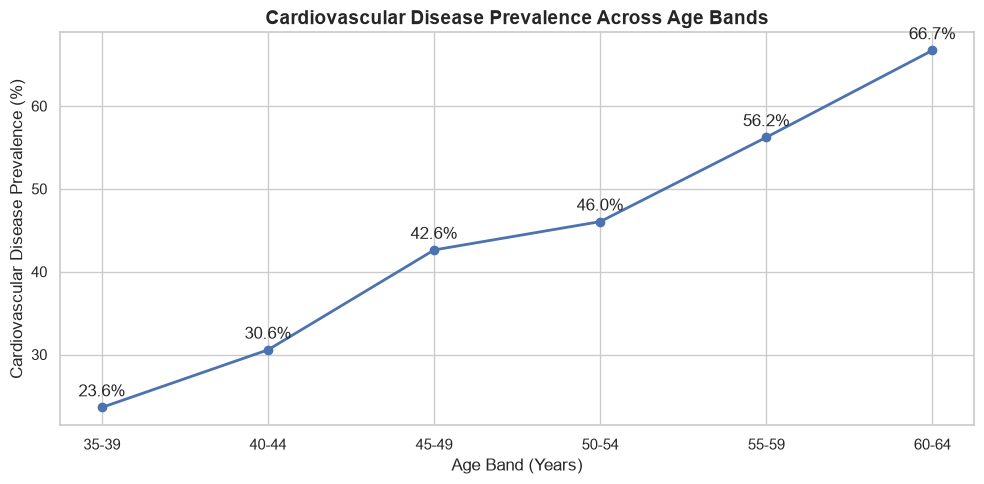

In [27]:
# ---------------------------------------------------------
# AGE-BASED CARDIOVASCULAR RISK TRAJECTORY
# ---------------------------------------------------------

age_band_edges = [
    29,
    35,
    40,
    45,
    50,
    55,
    60,
    65
]

age_band_labels = [
    "30-34",
    "35-39",
    "40-44",
    "45-49",
    "50-54",
    "55-59",
    "60-64"
]

cardio_data["age_band"] = pd.cut(
    cardio_data["age"],
    bins=age_band_edges,
    labels=age_band_labels,
    right=False
)

age_risk_profile = build_prevalence_profile(
    cardio_data,
    "age_band"
)

print("AGE-BASED CARDIOVASCULAR RISK PROFILE")
print("-" * 72)

display(
    age_risk_profile[
        [
            "Patient Group",
            "Patients",
            "CVD_Cases",
            "CVD_Rate"
        ]
    ].round(2)
)
# Exclude extremely small patient groups from the visual
# trajectory to avoid unstable prevalence estimates.
MINIMUM_GROUP_SIZE = 100

age_trajectory = age_risk_profile[
    age_risk_profile["Patients"] >= MINIMUM_GROUP_SIZE
].copy()

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    age_trajectory["Patient Group"],
    age_trajectory["CVD_Rate"],
    marker="o",
    linewidth=2
)

ax.set_title(
    "Cardiovascular Disease Prevalence Across Age Bands",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Age Band (Years)")
ax.set_ylabel("Cardiovascular Disease Prevalence (%)")

for _, row in age_trajectory.iterrows():
    ax.annotate(
        f"{row['CVD_Rate']:.1f}%",
        (
            row["Patient Group"],
            row["CVD_Rate"]
        ),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center"
    )

excluded_age_groups = age_risk_profile[
    age_risk_profile["Patients"] < MINIMUM_GROUP_SIZE
]

if not excluded_age_groups.empty:
    print(
        f"Visual trajectory excludes "
        f"{len(excluded_age_groups)} age group(s) with fewer than "
        f"{MINIMUM_GROUP_SIZE} patients."
    )
    
plt.tight_layout()
plt.show()

BMI CARDIOVASCULAR RISK PROFILE
------------------------------------------------------------------------


,Patient Group,Patients,CVD_Cases,CVD_Rate
0,Underweight,636,173,27.200
1,Healthy Range,25424,10115,39.790
2,Overweight,24620,12446,50.550
3,Obesity I,11938,7149,59.880
4,Obesity II,4229,2846,67.300
5,Severe Obesity,1763,1212,68.750


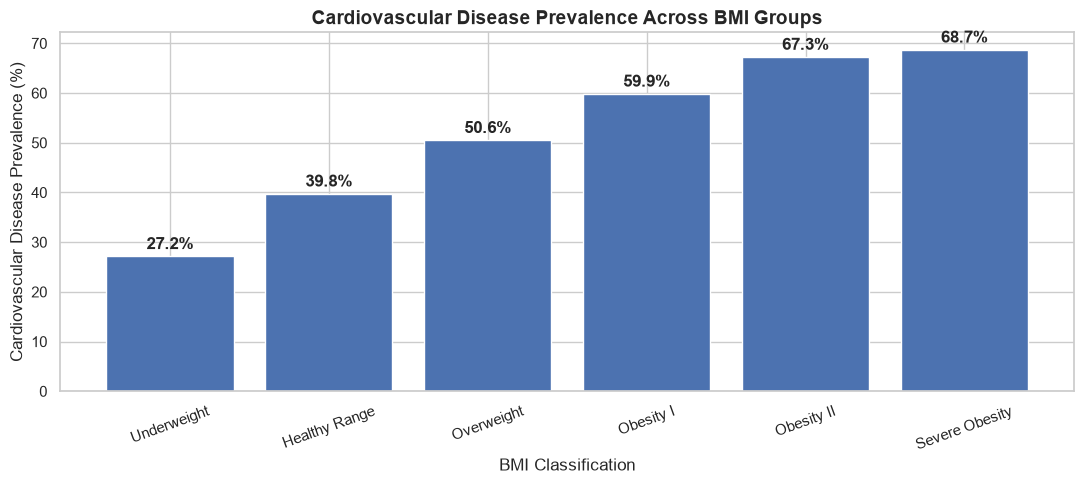

In [28]:
# ---------------------------------------------------------
# BMI CARDIOVASCULAR RISK LANDSCAPE
# ---------------------------------------------------------

bmi_boundaries = [
    0,
    18.5,
    25,
    30,
    35,
    40,
    np.inf
]

bmi_labels = [
    "Underweight",
    "Healthy Range",
    "Overweight",
    "Obesity I",
    "Obesity II",
    "Severe Obesity"
]

cardio_data["bmi_group"] = pd.cut(
    cardio_data["bmi"],
    bins=bmi_boundaries,
    labels=bmi_labels,
    right=False
)

bmi_risk_profile = build_prevalence_profile(
    cardio_data,
    "bmi_group"
)

print("BMI CARDIOVASCULAR RISK PROFILE")
print("-" * 72)

display(
    bmi_risk_profile[
        [
            "Patient Group",
            "Patients",
            "CVD_Cases",
            "CVD_Rate"
        ]
    ].round(2)
)

fig, ax = plt.subplots(figsize=(11, 5))

bars = ax.bar(
    bmi_risk_profile["Patient Group"],
    bmi_risk_profile["CVD_Rate"]
)

ax.set_title(
    "Cardiovascular Disease Prevalence Across BMI Groups",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("BMI Classification")
ax.set_ylabel("Cardiovascular Disease Prevalence (%)")

ax.tick_params(
    axis="x",
    rotation=20
)

for bar, rate in zip(
    bars,
    bmi_risk_profile["CVD_Rate"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.7,
        f"{rate:.1f}%",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

BLOOD PRESSURE CARDIOVASCULAR RISK GRID
------------------------------------------------------------------------


diastolic_band,<80,80-89,90-99,100-109,110+
systolic_band,,,,,
<120,22.120,24.510,36.340,50.000,NaN
120-129,32.310,35.760,40.790,57.890,50.000
130-139,52.700,57.920,63.570,70.670,63.640
140-159,77.270,81.770,83.460,83.450,87.760
160+,80.000,86.260,86.950,86.280,84.900


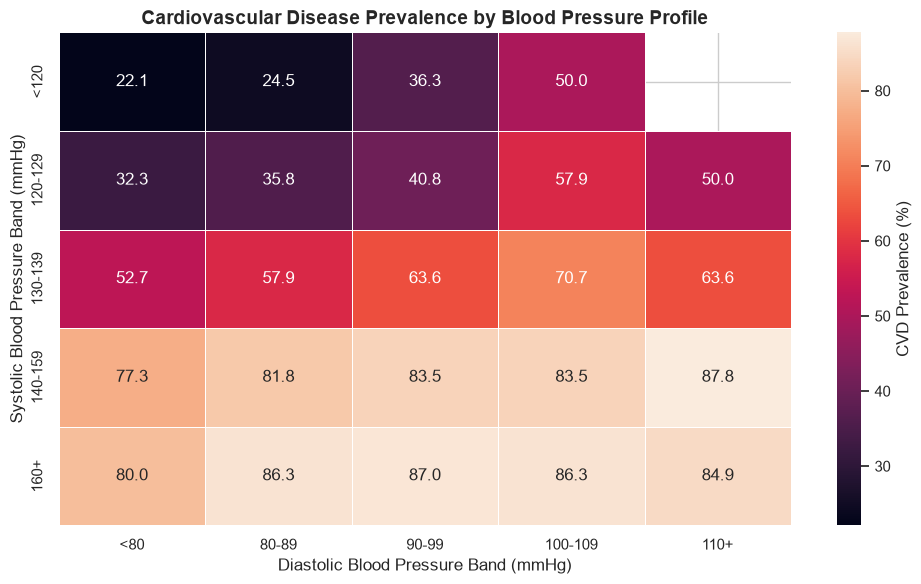

In [29]:
# ---------------------------------------------------------
# BLOOD PRESSURE RISK GRID
# ---------------------------------------------------------

systolic_bins = [
    70,
    120,
    130,
    140,
    160,
    251
]

systolic_labels = [
    "<120",
    "120-129",
    "130-139",
    "140-159",
    "160+"
]

diastolic_bins = [
    40,
    80,
    90,
    100,
    110,
    151
]

diastolic_labels = [
    "<80",
    "80-89",
    "90-99",
    "100-109",
    "110+"
]

cardio_data["systolic_band"] = pd.cut(
    cardio_data["ap_hi"],
    bins=systolic_bins,
    labels=systolic_labels,
    right=False
)

cardio_data["diastolic_band"] = pd.cut(
    cardio_data["ap_lo"],
    bins=diastolic_bins,
    labels=diastolic_labels,
    right=False
)

bp_risk_grid = cardio_data.pivot_table(
    index="systolic_band",
    columns="diastolic_band",
    values=TARGET_FEATURE,
    aggfunc="mean",
    observed=True
) * 100

print("BLOOD PRESSURE CARDIOVASCULAR RISK GRID")
print("-" * 72)

display(bp_risk_grid.round(2))

plt.figure(figsize=(10, 6))

sns.heatmap(
    bp_risk_grid,
    annot=True,
    fmt=".1f",
    linewidths=0.5,
    cbar_kws={
        "label": "CVD Prevalence (%)"
    }
)

plt.title(
    "Cardiovascular Disease Prevalence by Blood Pressure Profile",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Diastolic Blood Pressure Band (mmHg)")
plt.ylabel("Systolic Blood Pressure Band (mmHg)")

plt.tight_layout()
plt.show()

METABOLIC CARDIOVASCULAR RISK PROFILE
------------------------------------------------------------------------------


,Indicator,Patient Group,Patients,CVD_Cases,CVD_Rate
0,Cholesterol,Normal,51450,22401,43.540
1,Cholesterol,Above Normal,9296,5543,59.630
2,Cholesterol,Well Above Normal,7864,5997,76.260
3,Glucose,Normal,58332,27739,47.550
4,Glucose,Above Normal,5065,2981,58.850
5,Glucose,Well Above Normal,5213,3221,61.790


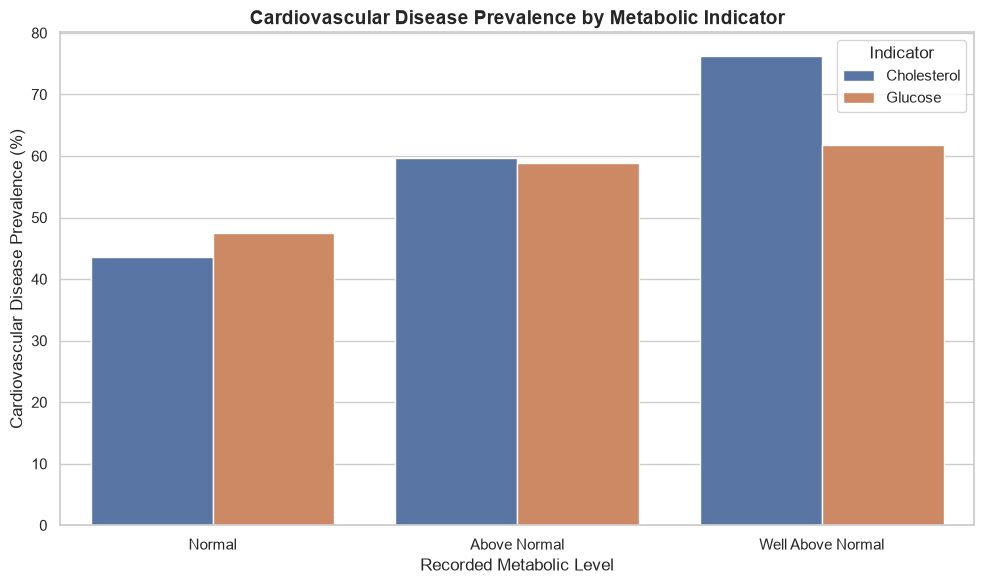

In [30]:
# ---------------------------------------------------------
# METABOLIC INDICATOR RISK PROFILE
# ---------------------------------------------------------

metabolic_labels = {
    1: "Normal",
    2: "Above Normal",
    3: "Well Above Normal"
}

metabolic_profiles = []

for feature in ["cholesterol", "gluc"]:

    feature_profile = build_prevalence_profile(
        cardio_data,
        feature,
        label_map=metabolic_labels
    )

    feature_profile["Indicator"] = (
        "Cholesterol"
        if feature == "cholesterol"
        else "Glucose"
    )

    metabolic_profiles.append(feature_profile)


metabolic_risk = pd.concat(
    metabolic_profiles,
    ignore_index=True
)

print("METABOLIC CARDIOVASCULAR RISK PROFILE")
print("-" * 78)

display(
    metabolic_risk[
        [
            "Indicator",
            "Patient Group",
            "Patients",
            "CVD_Cases",
            "CVD_Rate"
        ]
    ].round(2)
)

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=metabolic_risk,
    x="Patient Group",
    y="CVD_Rate",
    hue="Indicator",
    ax=ax
)

ax.set_title(
    "Cardiovascular Disease Prevalence by Metabolic Indicator",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Recorded Metabolic Level")
ax.set_ylabel("Cardiovascular Disease Prevalence (%)")

plt.tight_layout()
plt.show()

LIFESTYLE CARDIOVASCULAR SIGNAL BOARD
------------------------------------------------------------------------------


,Lifestyle Factor,Patient Group,Patients,CVD_Cases,CVD_Rate
0,Smoking,No,62574,31114,49.720
1,Smoking,Yes,6036,2827,46.840
2,Alcohol Consumption,No,64949,32196,49.570
3,Alcohol Consumption,Yes,3661,1745,47.660
4,Physical Activity,No,13493,7188,53.270
5,Physical Activity,Yes,55117,26753,48.540


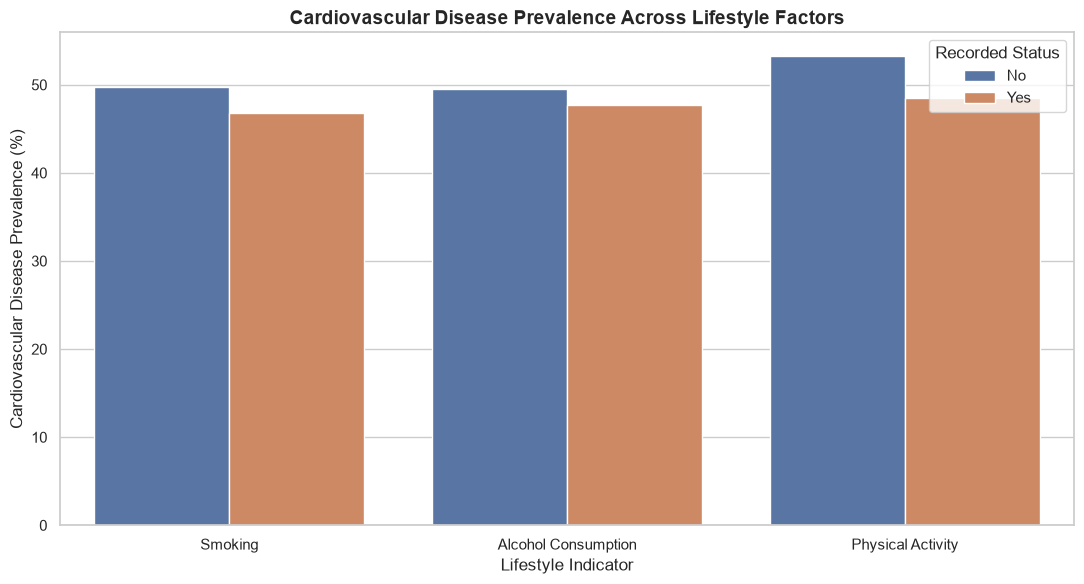

In [31]:
# ---------------------------------------------------------
# LIFESTYLE CARDIOVASCULAR SIGNAL BOARD
# ---------------------------------------------------------

lifestyle_features = {
    "smoke": "Smoking",
    "alco": "Alcohol Consumption",
    "active": "Physical Activity"
}

lifestyle_profiles = []

for feature, readable_name in lifestyle_features.items():

    feature_profile = build_prevalence_profile(
        cardio_data,
        feature,
        label_map={
            0: "No",
            1: "Yes"
        }
    )

    feature_profile["Lifestyle Factor"] = readable_name

    lifestyle_profiles.append(feature_profile)


lifestyle_risk = pd.concat(
    lifestyle_profiles,
    ignore_index=True
)

print("LIFESTYLE CARDIOVASCULAR SIGNAL BOARD")
print("-" * 78)

display(
    lifestyle_risk[
        [
            "Lifestyle Factor",
            "Patient Group",
            "Patients",
            "CVD_Cases",
            "CVD_Rate"
        ]
    ].round(2)
)

fig, ax = plt.subplots(figsize=(11, 6))

sns.barplot(
    data=lifestyle_risk,
    x="Lifestyle Factor",
    y="CVD_Rate",
    hue="Patient Group",
    ax=ax
)

ax.set_title(
    "Cardiovascular Disease Prevalence Across Lifestyle Factors",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Lifestyle Indicator")
ax.set_ylabel("Cardiovascular Disease Prevalence (%)")

ax.legend(
    title="Recorded Status"
)

plt.tight_layout()
plt.show()

### Exploratory Analysis Findings

The processed cardiovascular dataset remained nearly class-balanced, with cardiovascular disease recorded in **49.47% of the 68,610 analysed patients**. This balance allows disease prevalence patterns to be examined without a dominant outcome class overwhelming the analysis.

A strong age-related trajectory was observed. Among age groups with sufficient patient representation, CVD prevalence increased from **23.61% in patients aged 35–39 years** to **66.72% in the 60–64 year group**, representing an observed difference of more than 43 percentage points. The 30–34 age band contained only four patients and was therefore excluded from the visual risk trajectory to avoid presenting an unstable prevalence estimate as a population-level pattern.

BMI demonstrated a progressive cardiovascular disease gradient. CVD prevalence increased from **39.79% in the healthy BMI range** to **50.55% among overweight patients**, **59.88% in Obesity I**, and **68.75% among patients with severe obesity**. This consistent increase indicates a strong association between higher BMI categories and cardiovascular disease prevalence within the analysed population.

Blood pressure produced one of the clearest clinical patterns in the exploratory analysis. Patients with systolic pressure below 120 mmHg and diastolic pressure below 80 mmHg recorded a CVD prevalence of **22.1%**, while multiple elevated blood-pressure profiles exceeded **80% prevalence**. The joint systolic-diastolic risk grid therefore revealed substantial disease separation across blood-pressure profiles.

Both cholesterol and glucose levels showed increasing disease prevalence at elevated recorded levels. The cholesterol gradient was particularly pronounced, with **76.26% CVD prevalence in the well-above-normal cholesterol group**. The corresponding well-above-normal glucose group recorded **61.79% prevalence**, suggesting a stronger unadjusted disease separation across cholesterol categories.

Among the recorded lifestyle indicators, physical activity showed the clearest prevalence difference. CVD was observed in **53.27% of inactive patients** compared with **48.54% of active patients**. Smoking and alcohol indicators showed smaller and counterintuitive raw differences. These observations are treated as unadjusted associations and are not interpreted as causal or protective effects, since demographic and clinical differences between patient groups may influence the observed prevalence rates.

Overall, the exploratory analysis identifies **age, BMI, blood pressure, and cholesterol** as prominent candidate signals for cardiovascular disease prediction. These exploratory findings will next be compared with the correlation structure of the processed dataset and the predictive behaviour of multiple machine learning algorithms.